# PCHN63101 Statistical Modelling Workshop
In the accompanying lesson to this workshop we explored the general concept of a statistical model as a method of capturing the variance inherent within a dataset. We first saw how to define a descriptive measure of variance, before exploring how this notion of random variation can be formalised using concepts from the world of *probability*. Specifically, every value we measure is conceptualised as a random draw from a particular probability distribution. This distribution provides the *model* of our data-generating process and thus formalises the probabilistic behaviour of our measurements. The shape of every probability distribution is controlled by a number of *parameters* that, either directly or indirectly, inform the *expected value* and *variance* of the distribution. These can be thoughts of as the *most probable* value and the *width*. A statistical model is then concerned with assuming some population distribution for a given data set and then connecting the parameters of the distribution to the data via a *mean function* and a *variance* function.    

At present, some of these ideas may feel a bit abstract. However, over the coming weeks we will start to see them put into action and all this information should become clearer. In this workshop, the focus will be on providing more intuition about all these topics by demonstrating some of these ideas in code. This will allow you to play around with each idea, providing a less abstract feeling to the concept by observing how the output of the code changes with different inputs. In general, playing with code is one of the *best* ways for gaining intuition about many mathematical concepts.

## Understanding Variance
To begin, we will start with the basic concept of variance as the degree to which measured data points *differ* from each other. You should understand from the lesson one way in which we can capture the degree of variation, through the calculation of the sample variance. The equation for the sample variance is

$$
\text{Var}\left(y\right) = \frac{\sum\left(y_{i} - \bar{y}\right)^{2}}{n-1}
$$

where $n$ indicates the sample size, $\bar{y}$ indicates the mean and the symbol $\Sigma$ indicates a sum across all the data points (we will explain this notation in more detail in a future lesson). Although not the only conceivable way of capturing how much data varies, this is the formal definition of *variance* within statistics. In the plots below, we can see how this value scales with our visual intuition about *variation* as the *spread of values around 0*. 

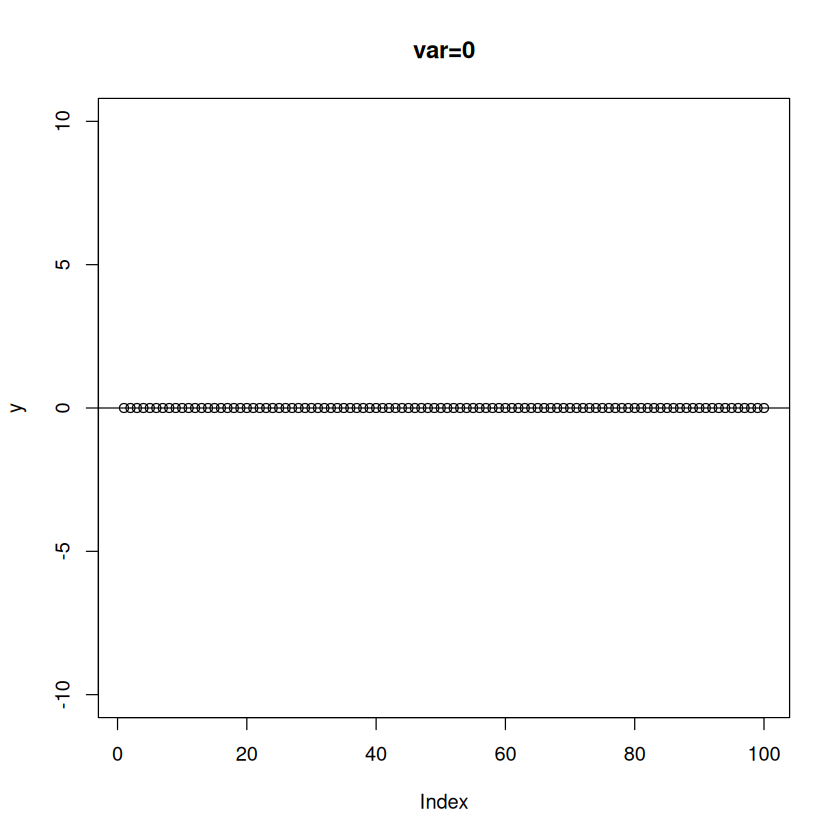

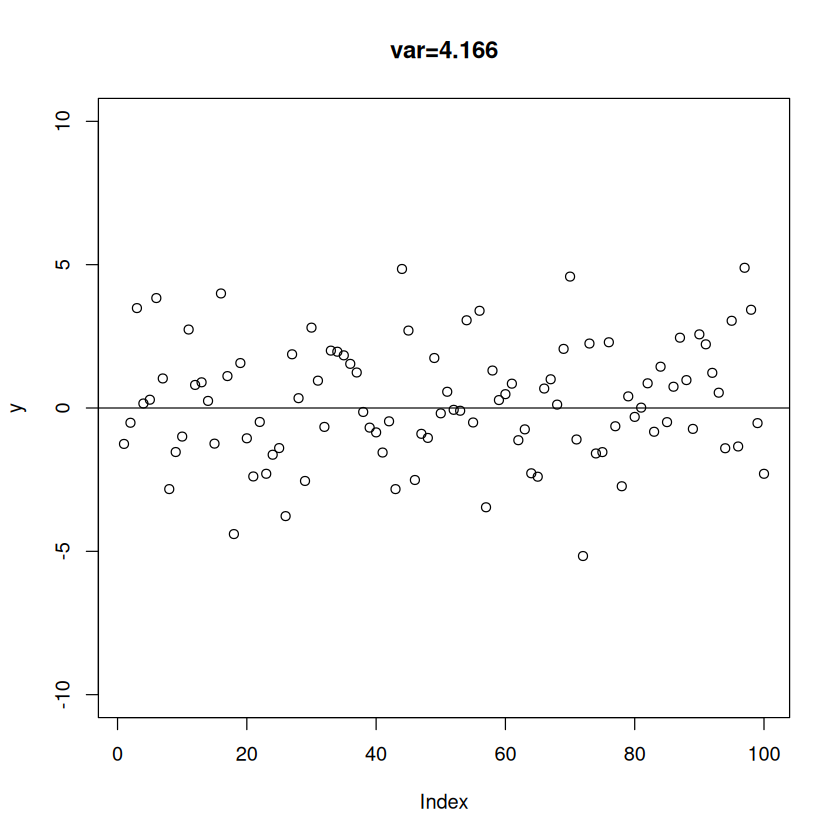

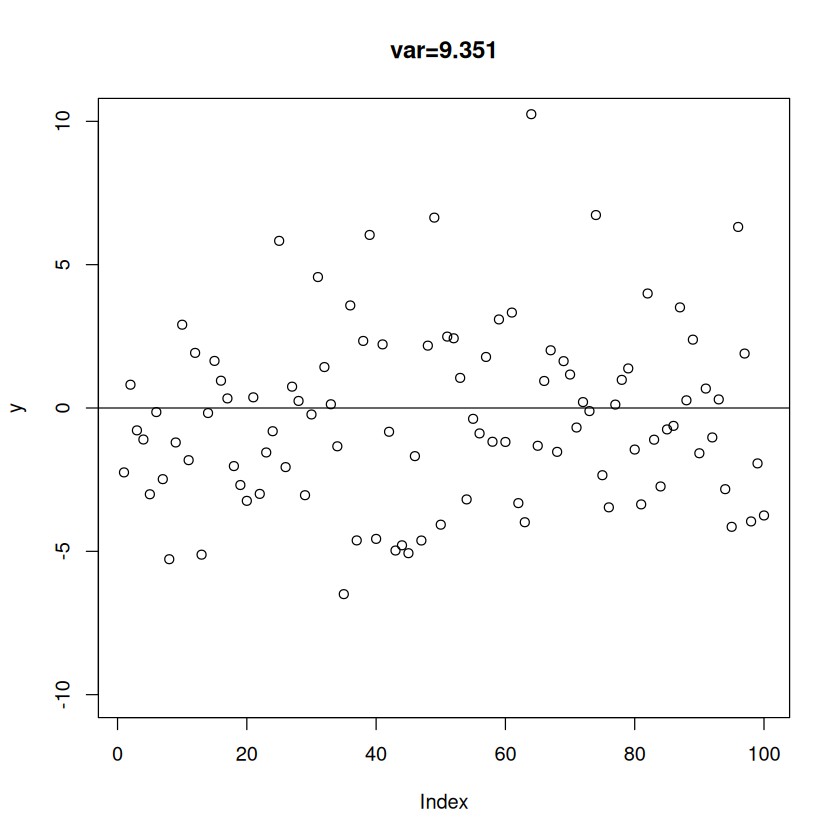

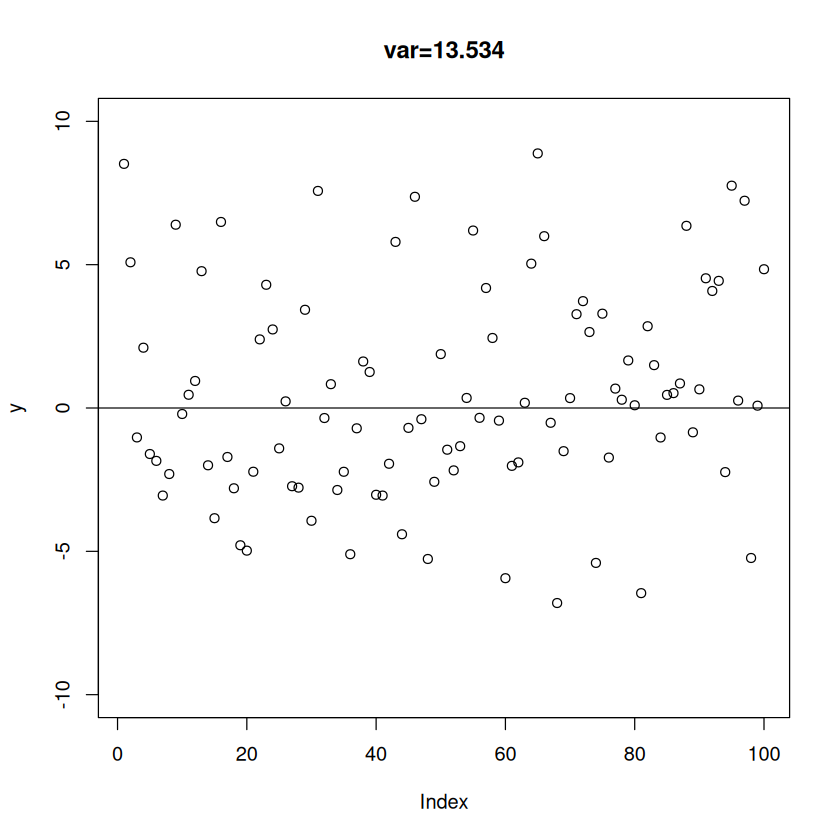

In [1]:
set.seed(123)
for (i in 0:3){
   y      <- rnorm(n=100, mean=0, sd=sqrt(i*5))
   sigma2 <- var(y)
   plot(y, ylim=c(-10,10), main=paste0("var=",round(sigma2,3)))
   abline(h=0)
}

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Try replacing the use of the <code>var()</code> function above with the full equation for the sample variance. Check the output against the values given by <code>var()</code> to make sure you are correct. (HINT: if you are using the equation above, you can replace &Sigma; with the <code>sum()</code> function and &#563; with the <code>mean()</code> function).
</div>

## Sources of Variance
Although we can now see how variance is captured, this is only ever a precursor to trying to *explain* variance. A core concept here is that data can vary for *two* reasons: systematic patterns *or* random noise. To see this, consider the code and plots below

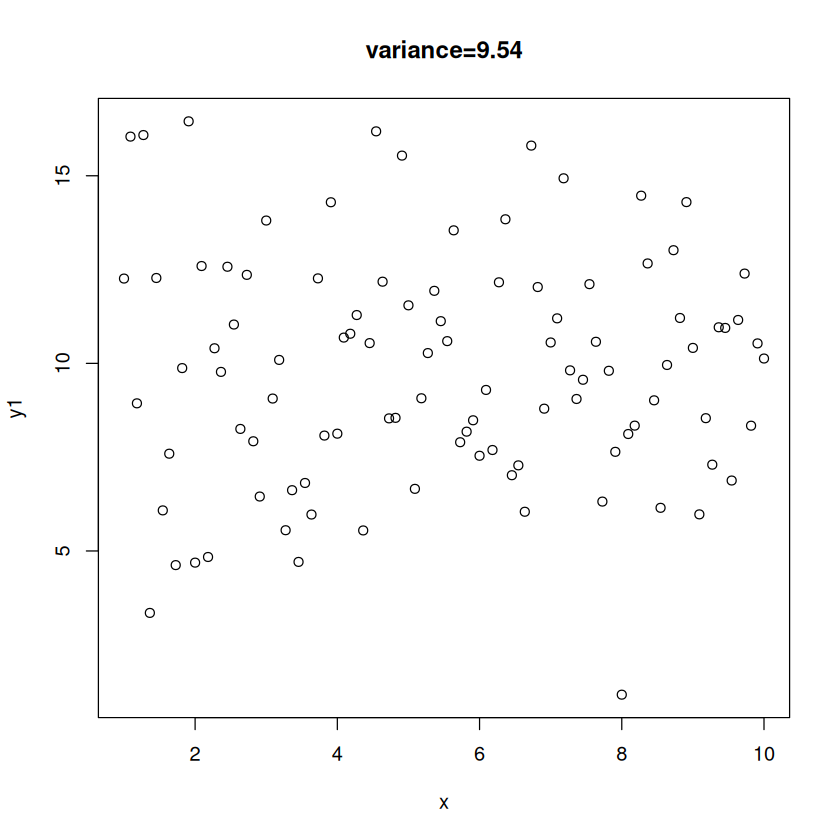

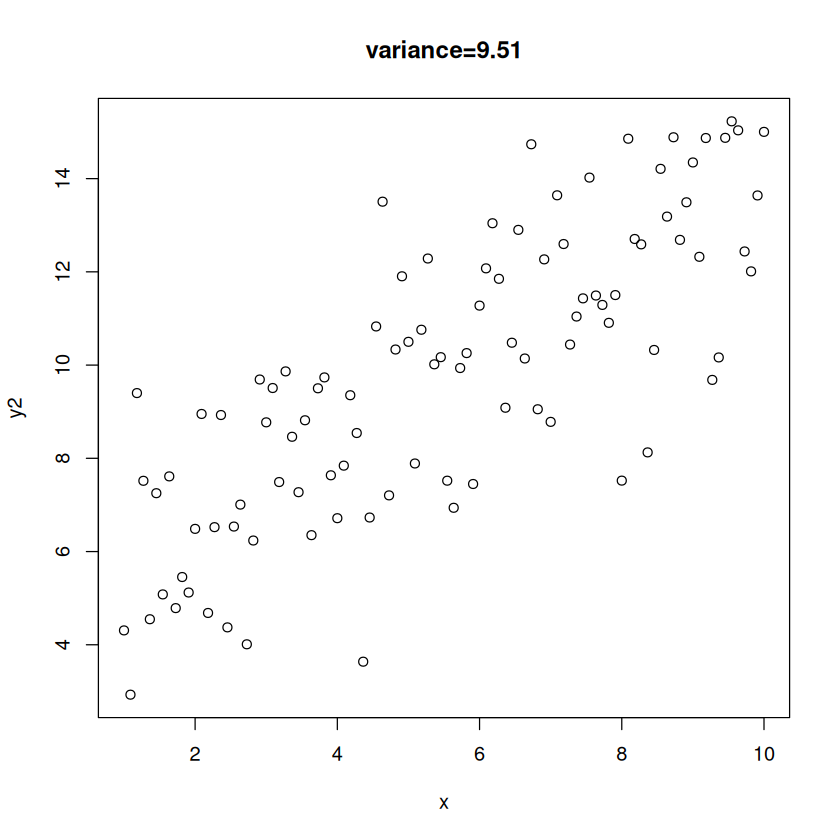

In [2]:
set.seed(666)
x <- seq(1, 10, length.out = 100)

y1 <- rnorm(100, 10, 3)                 # pure noise
y2 <- (5 + 0.9*x) + rnorm(100, 0, 1.68) # linear pattern + pure noise

var1 <- round(var(y1),2)
var2 <- round(var(y2),2)

plot(x, y1, main=paste0("variance=",var1)) 
plot(x, y2, main=paste0("variance=",var2))


The first plot contains random noise drawn from a normal distribution, completely unrelated to the predictor variable $x$. The second plot contains a linear pattern between $x$ and $y$, with some random normal noise added. Both sets of data have nearly the same value in terms of sample variance, yet the second plot shows a much clearer pattern between $x$ and $y$. This highlights that variance itself cannot tell us whether the variation is systematic or random. That is the job of the statistical model. Any clear patterns within the data represent the *predictable* element of the variance, whereas any additional random noise represents the *unpredictable* element of the variance. The job of any statistical model is therefore to take the total amount of variance and *partition* it into the amount attributable to predictable patterns and the amount attributable to random noise.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Imagine that the second plot above corresponds to an investigation into how mood, as measured using a questionnaire, improves based on the number of hours sleep someone has the night before. Redraw the plot so that the x-axis is labelled <code>hours of sleep</code> and the y-axis is labelled <code>mood</code>. After collecting data from 100 different people, there appears to be some universal pattern between hours of sleep and mood. However, the relationship is not perfect. Why is that? Can you think of different reasons why we still have an <i>unpredictable</i> element to these data?
</div>

## Random Variables as Variance Generators
Knowing that variance, both systematic and random, is the primary information we want to capture leads to the obvious question of *where does variance come from*? Although the true reasons for variation in measurements are likely to be deep, complex and data-dependent, this question can be addressed in a more general fashion by appealing to probability. The reason our measurements vary is because the phenomena we are measuring is a *random variable*. By definition, this means that every time we make an observation, the value will change. Although this change is *unpredictable* in the short-term, it has a regularity and pattern in the long-term, as governed by its *probability distribution*. The parameters of the probability distribution control its shape and thus control both the *predictable* and *unpredictable* elements of the data.

When conceptualising our measurements as realisations of a random variable, we can think of a random variable as a *variance generator*. The distribution associated with the random variable tells us, in an idealised mathematical fashion, *where the data came from*. Every time we take a measurement of that random variable, we are taking a random draw from that distribution. This process, no matter the actual real-world physical phenomena that govern it, creates the variance that we see in our data. Because of this, our interest lies in the nature of the distribution that has generated our data. If we know the form of the distribution and its parameter values, we can answer all questions about where our data have come from and thus know everything we need to know about our phenomena of interest.

### Discrete Outcome Example
We will now explore some of the ideas of a random variable in a little more detail. To start, we will focus on a *discrete* random variable associated with a *discrete* probability distribution. 

Imagine an experiment where subjects are exposed to a series of very faint auditory stimuli. After each presentation, they are asked whether they heard anything or not. In total, each subject takes part in 20 trials, where the outcome variable is a count of the number of "yes" responses. Very generally, any variable that represents a *count* of the total number of one type of response in a series of binary trials (e.g. responding "yes" or "no") can be modelled as a *binomial random variate* of the form

$$
y_{i} \sim \mathcal{B}\left(n,p\right),
$$

where $n$ is the number of trials and $p$ is the probability of giving a specific response (e.g. "yes"). In this example, we already know that $n=20$, because each subject takes part in 20 trials. Let us say, for the purpose of illustration, that we know that the stimuli are around around 60% detectable, so $p=0.6$. Thus, our proposed data-generating process is

$$
y_{i} \sim \mathcal{B}\left(20,0.6\right).
$$

Here, the variation in the count of "yes" responses across subjects is generated by the fact that this is a Binomial random variate drawn from a distribution with a particular *mean* and *variance*. These elements control both the average count of "yes" responses across subjects, as well as how variable this count will be. Thus, everything we need to know about this experiment is captured within the data-generating model above.

We can use `R` to simulate data like this using the `rbinom()` function (for `r`andom `binom`ial). For instance, we can generate 20 subjects from this experiment like so

In [3]:
y <- rbinom(n=20, size=20, prob=0.6)
y

[1]  8 10  9 13 13 13  9 10 11 11 12 13  8  8  9 10  9 13 12 13

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Try running this code a few times. Do you get the same values? Is there any way to predict what those values will be? Think about what this represents in terms of running an experiment again and again with different subjects. 

<i>BONUS</i> How can you use the `set.seed()` function to make sure the random draw always gives you the same values every time? Why is this useful?
</div>

It should be clear at this point that we have no way of predicting what any single response will be, nor how this will change from subject-to-subject. Thus, this variable is *unpredictable* in the short-term. This is the random noise component. However, in the *long-term* there is a pattern that we can use to make *general* predictions about the data. This is the systematic component. 

Both the *random noise component* and *systematic component* are described by different elements of the probability distribution. The random noise is captured by the *variance* and the systematic pattern is captured by the *expected value* (more generally known as the *mean*). All probability distributions have some concept of both these elements. For the Binomial distribution, these are linked to the parameters in the following way

$$
\begin{alignat*}{1}
    E(y_{i})   &= np \\
    \text{Var}\left(y_{i}\right) &= np(1-p)
\end{alignat*}
$$

Thus, we can say how many "yes" responses we expect on average and how variable those responses are expected to be from subject-to-subject.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Create a histogram of the data generated from the binomial distribution above. Try calculating the expected value and variance using the formulas above. Do they appear to agree with what you can see? Try calculating these directly from the data using the <code>mean()</code> and <code>var()</code> functions. Are they close to the values calculated directly from the parameters? What happens if you make the sample size very large (i.e. 10,000)?
</div>

### Continuous Outcome Example
As another example, consider the same experiment concerned with the detection of faint auditory stimuli. This time, rather than subjects responding "yes" or "no", we ask them to press a button as soon as they are certain they can hear something. We then measure their *reaction time* (RT) in milliseconds from the start of the auditory stimulus to when they press the button to indicate they can hear it. Because RT is a continuous measure, we can therefore use a continuous distribution as our model. The usual choice would be to treat RT as a *normal random variate* of the form

$$
y_{i} \sim \mathcal{N}\left(\mu, \sigma^{2}\right)
$$

Again, for the purpose of illustration, let us say that we know that, on average, subjects can detect the stimuli within around 500ms, varying by around 50ms on average. So we can set $\mu = 500$ and $\sigma = 50$.

As with the binomial example, we can use `R` to simulate 20 subjects from this experiment using the `rnorm()` function (for `r`andom `norm`al)

In [4]:
y <- rnorm(n=20, mean=500, sd=50)
y

[1] 514.4569 527.4477 525.3301 470.9504 462.2709 536.5611 487.0125 536.0715
 [9] 466.5057 467.7797 437.2868 510.8920 552.5413 423.5084 552.7628 503.1741
[17] 575.4391 508.9341 499.3204 494.0447

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Beyond the magnitude of these values, what is the most obvious difference between drawing data from a binomial distribution and data from a normal distribution? What does this tell you about the suitability of these distributions for different kinds of data?
</div>

## Determining Distributions from Data
Given what we have said above, if we conceptualise our outcome measurements as a random variable we therefore have to decide on what probability distribution to use to model its behaviour. This is one of the trickiest aspects of this framework. In reality, unless you are using Bayesian methods, you will have very little say in this aspect. Most classical statistical techniques are built from the assumption of *one specific distribution* and we generally just have to hope that this distribution will work well for us. This means that, although there are *hundreds* of possible probability distributions, you will only ever see a handful being used in the wild. Indeed, in terms of data-generating models, applied statistics often leans heavily on the following 4:

1. Normal
2. Poisson
3. Binomial
4. Gamma

We do not need to go into any particular detail about these, especially as our focus on this unit is *exclusively* the normal distribution. However, it does beg the question how only 4 distributions can possibly accommodate all possible data that we might collect? The answer is that these distributions will *not* always be a perfect match. Although some special cases that use alternative distributions are available, our general approach is to decide which of the available options is *close enough*. We then apply it to the data and try to understand whether the conclusions from that model are valid enough to be useful.

### How Do We Choose a Distribution?
As covered in the accompanying lesson, the first choice we need to make is whether our outcome is *continuous* or *discrete*. Could the outcome have an infinite number of possible values within a range? If so, it is *continuous*. Is the outcome constrained to only a finite number of values (usually whole numbers)? If so, it is *discrete*. From there, we can decide, from the options available to us, which distribution is most closely aligned with our data. For instance, from the 5 examples given above, we have:

- *Continuous*
    - Normal
    - Gamma
- *Discrete*
    - Poisson
    - Binomial

So, in each case, we might first determine the *type* of outcome we have and then decide, from our small number of options, which distribution to select. We do not need to go into details about this right now, because our focus on this unit (and indeed, most of the focus of classical statistics) is on the use of the *normal distribution*. We will see later in the course the more complex methods we can use if we wish to assume other kinds of distribution.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> A common type of data collected in Psychology is questionnaire scores. For instance, each subject completes a questionnaire where each item consists of a Likert scale (pronounced <i>Lick-ert</i>) from 1-5. The total score is simply the sum of the scores for each item. Say there are 5 items, what is the <i>maximum</i> score a subject could achieve? What is the <i>minimum</i> score a subject could achieve? This is our <i>range</i>. Is this outcome <i>continuous</i> or <i>discrete</i>? What if we divided the total score by the number of items to create an <i>average score</i>. Does this change anything?
</div>

### How Do We Check the Distribution?
Although the number of available distributions is always *limited*, we still need to check whether our chosen distribution is suitable. However, this is easier said than done. Remember, the distribution we choose represents our *population*. We conceptualise our sample as a random draw from that distribution. So, how easily can we use the information in the sample to infer something about the population distribution? This is the broad question at the heart of all applied statistics.

As an example, the code below shows 9 instances of drawing data from a normal distribution. Remember, because we are simulating these data we know for a *fact* that a normal distribution is correct. In this example, $n = 5$, which is a very small sample. Notice how difficult it is to assess the actual form of distribution from the sample. Based on any one of these samples, would you be confident in declaring that a normal distribution is correct?

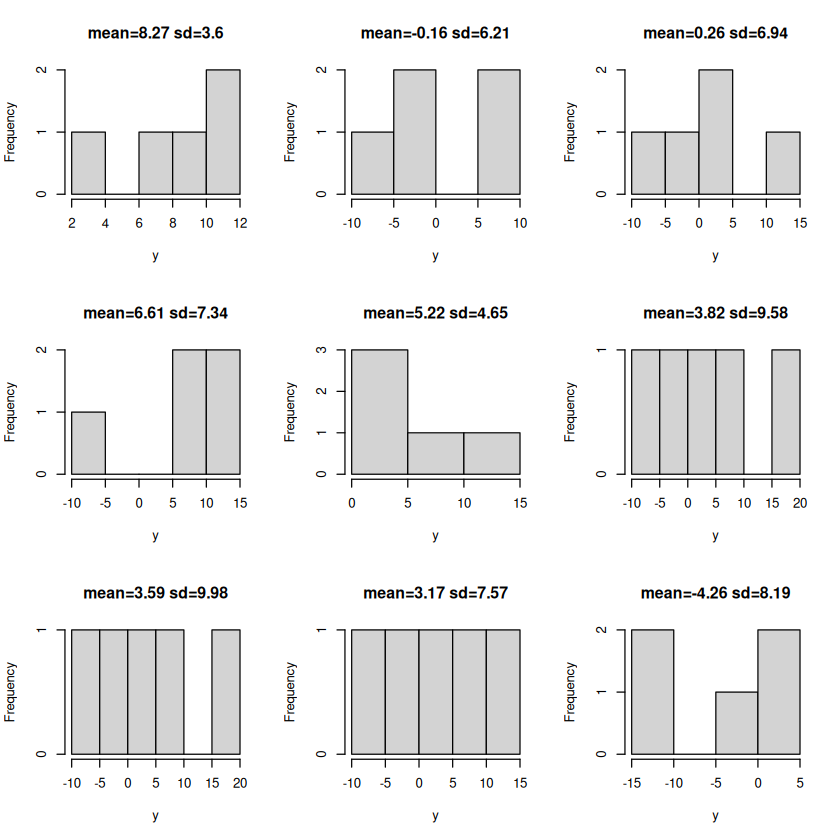

In [5]:
n     <- 5
mu    <- 5
sigma <- 8

par(mfrow=c(3,3))

for (i in 1:9){
    y            <- rnorm(n, mean=mu, sd=sigma)
    sample.mu    <- mean(y)
    sample.sigma <- sd(y)
    
    hist(y, main=paste0("mean=",round(sample.mu,2),
                        " sd=", round(sample.sigma,2)))
}

par(mfrow=c(1,1)) # reset the display

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Alter the code above for different values of <code>n</code>. At what sample size do you think assuming normality based on the shape of the sample distribution is reasonable? What does this suggest about how reliable it is to use the basic shape of the sample distribution to determine the population distribution? Now consider how variable the estimates are for the <i>mean</i> and <i>standard deviation</i>, as written in the title of each histogram. Remember, the true values are a mean of 5 and a standard deviation of 2. How does this variability change with different values of <code>n</code> and what does this suggest about our ability to accurately estimate the population parameters from a sample?
</div>

The point of this exercise is to highlight that we cannot be too fussy about how perfectly matched our data are to our proposed distribution. In many cases, it is very difficult to know because the variety of shapes we can get is quite large. It is common for students to be a bit obsessive over this, but hopefully this simulation highlights how our obsessiveness needs to scale with sample size. If we have $n = 10,000$ and the distribution does not look normal, then we are allowed to be concerned. However, if $n = 6$, we have to realise that we are not always going to be able to tell. We will see later in the unit how this scaling is one of the reasons why inferential tests of distributional assumptions are usually a waste of time compared to simply *looking* at the distribution itself.

### What If We Are Wrong?
Of course, our main concern throughout all of this is whether we are *right* or *wrong* about the chosen distribution. However, this is not really the correct perspective. Remembering the famous quote from George Box, we will *always* get the distribution "wrong" because the distribution is a *model* and no model is perfect. Indeed, the distributions themseleves are mathematical abstractions of reality. They do not really *exist* in the sense that they are *descriptions* of what we see around us. As with any description, the distributions inherently require some degree of simplification. Our aim is then to choose something that is *as close as possible* such that the numbers produced by the model are useful. 

All that being said, we can still make choices that are *more appropriate* or *less appropriate*. Perhaps the clearest example of this is choosing between a *continuous* or *discrete* probability distribution. As an example of what can happen if we neglect the *type* of distribution, let us go back to the auditory stimuli example from earlier. Previously, we used a binomial distribution to represent the number of "yes" responses given by each subject under different conditions. However, you may have noticed from the histograms that this does not seem all that dissimilar to a normal distribution. They are both symmetric with some clear central value and tails that imply decreasing probability the further from the mean we go. Indeed, if we take $\mu = np$ and $\sigma = \sqrt{np(1-p)}$ then we can create a *normal approximation* to the binomial, as shown below.

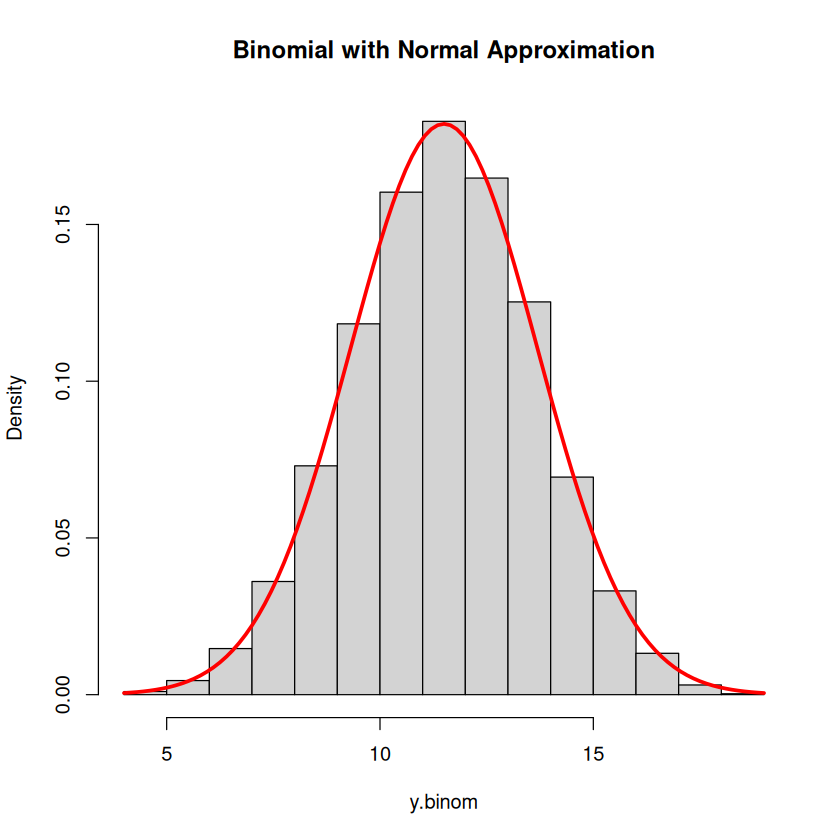

In [6]:
# binomial random variable
n       <- 20
p       <- 0.6
y.binom <- rbinom(n=10000, size=n, prob=p)

# normal approximation
mu    <- n*p
sigma <- sqrt(n*p*(1-p))

# binomial histogram and normal density overlay
hist(y.binom, freq=FALSE, main="Binomial with Normal Approximation") 
curve(dnorm(x+0.5, mean=mu, sd=sigma), add=TRUE, col="red", lwd=3)


So, what would happen if we decided to use a normal distribution instead of a binomial distribution as the model for this experiment? We would have a very similar *mean* and very similar *variance*, so in terms of the parameters of the distribution our conclusions would likely be the same. Indeed, the mean of the binomial is allowed to be a fractional value and thus is allowed to disagree with the discrete nature of the variable in question. So, from this perspective, there seems to be no harm done. 

However, the key to understanding the problems with this approach lie with what this model *implies* about the data. To see this clearly, let us have a look and see what the binomial distribution says is the probability of getting 21 "yes" responses from only 20 trials. Now, this is not the most sensible question in the world, but it is one where we should know the answer already. If the subject participated in 20 trials then it is *impossible* for them to provide 21 "yes" responses. So what does the binomial distribution say?

In [7]:
pbinom(q=21, size=n, prob=p, lower.tail=FALSE)

[1] 0

So, quite rightly, the binomial distribution agrees that it would be *impossible* to have a subject give 21 "yes" responses when there are only 20 trials. Now, let us see what the normal approximation says

In [8]:
pnorm(q=21, mean=mu, sd=sigma, lower.tail=FALSE)

[1] 1.996199e-05

So, althought this is a small value ($p = 0.00002$), it is not 0. So the normal probability model tells us that there is *some non-zero chance* of a subject giving 21 responses from only 20 trials. This is because the normal distribution extends to infinity in either direction and so there is always some non-zero probability of *every value*.  This is clearly nonsense, but highlights the sort of thing that happens when an *inappropriate* distribution is chosen to model an experiment.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Now consider the opposite situation, where someone decides to model a <i>continuous</i> outcome using the binomial distribution. What problems do you think could occur?
</div>

## Mean Functions and Variance Functions
So far in this workshop, all the distributions we have seen have used a *constant value* for their parameters. In terms of trying to model complex data, this approach is too limited. A much more flexible option is to define a *mean function* and a *variance function*. These allow the expected value and the variance of the distribution to change depending upon the value of other variables. This embeds the idea that, under different circumstances, we imagine that we are sampling data from *different* distributions. To be clear, we do not mean entirely different forms of distribution (e.g. a normal and a binomial), rather that the *parameters* of the distribution change. This is a key idea in statistical modelling that we will explore further in this section. 

<div class="alert alert-block alert-danger"> 
<b>KEY POINT</b> You can think of the mean function and variance functions as  <i>rules</i> that dictate what value the mean will have and what value the variance will have, depending upon the specific observation. For instance, those rules might encode how the value of the mean changes across experimental conditions, or with the value of some other continuous measurement. These rules <i>define</i> our model of the data.
</div>

### Normal Example
We will start with the example of a normal distribution, as this will be simpler than the binomial example. To begin with, the most basic form of a normal distribution model is as follows

$$
\begin{alignat*}{1}
    y_{i}              &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    E(y_{i})           &= \mu_{i}                             \\
    \text{Var}(y_{i})  &= \sigma^{2}_{i}. 
\end{alignat*}
$$

In words, this says that observation $i$ is drawn from a normal distribution parameterised by a mean $\mu_{i}$ and variance $\sigma^{2}_{i}$. The *expected value* (i.e. the mean) is given by $\mu_{i}$ and the *variance* is given by $\sigma^{2}_{i}$. To complete this model, we use a *mean function* and a *variance function* to apply rules that assign numeric values to both $\mu_{i}$ and $\sigma^{2}_{i}$. For instance, let us continue with the detection of auditory stimuli example from above. In that context, we might define that $\mu_{i} = 500$. Thus the mean function states that, irrespective of the value of $i$, the mean will always be 500ms. We could do a similar thing with the variance function by setting, for example, $\sigma_{i} = 50$.

Before we start seeing how this idea can be applied in more general situations, let us see how this could be implement as a *data simulation* in `R`. The advantage here is that we can use `R` to define both the mean and variance functions in code. This is helpful because it shows how the more abstract ideas from a mathematical models can be translated into physical code. In this instance, all we need to do is sample from a normal distribution where the mean function always returns $500$ and the variance function always returns $50^2$. Simulating 20 subjects from this scenario can be achieved using the following code

In [9]:
mean.func <- function(i){
    mu <- 500
    return(mu)
}

var.func <- function(i){
    sigma2 <- 50^2
    return(sigma2)
}

nsubs <- 20
y     <- rep(0,nsubs)

for (i in 1:nsubs){
    y[i] <- rnorm(n=1, mean=mean.func(i), sd=sqrt(var.func(i)))
}

y

[1] 453.9976 488.3047 580.3477 563.0550 492.8850 511.3082 455.9672 474.6151
 [9] 548.6244 467.4109 572.3889 565.8065 516.1013 514.5909 391.1684 485.9843
[17] 528.4904 496.2900 506.3914 407.7790

So, this is now equivalent to the model

$$
\begin{alignat*}{2}
    y_{i}              &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    E(y_{i})           &= \mu_{i} = 500             &\text{(Mean function)}  \\
    \text{Var}(y_{i})  &= \sigma^{2}_{i} = 50^2     &\text{(Variance function)}, 
\end{alignat*}
$$

and the code is currently just an overly-complicated way of writing `rnorm(n=20, mean=500, sd=50)`. However, we will now see how we can use this *structure* to adapt the model so that the parameter $\mu_{i}$ changes depending upon additional information. This will lead to a data-generating model that can *accommodate* our experimental manipulations.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Have a play around with the value used for <code>mu</code> and the value used for <code>sigma2</code>. Make sure it is clear how the value for <code>mu</code> is affecting the <i>systematic</i> element of the generated data and how the value for <code>sigma2</code> is affecting the <i>random</i> element of the generated data. For instance, what happens if your remove the random element entirely by setting <code>sigma2 <- 0</code>? What happens if you make it very small instead? What happens when you choose a different value for <code>mu</code>?
</div>

#### Modelling an Experimental Manipulation
To see how we can make this framework more useful, imagine that we perform some sort of experimental manipulation. For instance, perhaps we get a different group of subjects to listen to some very loud music for 5 minutes. We then get them to try and detect the same faint auditory stimuli as well. Assuming that this manipulation makes subjects *worse* at detecting the stimuli, we could conceptualise this as an *increase* in the average reaction time. In the context of our model, the experimental manipulation has caused $\mu$ to change. For the sake of argument, let us say that after listening to the loud music $\mu = 700$ and the data-generating process becomes

$$
y_{i} \sim \mathcal{N}\left(700,50\right).
$$

So, we now have a situation where the mean function *changes* the value that it returns depending upon the condition of the experiment. In other words, the rule that governs the value of the mean depends upon which experimental condition the data comes from. Thus this new rule defines a new model of our experimental scenario, where the average RT changes between the conditions. Importantly, this captures the *effect* of our experimental manipulation in terms of a 200ms shift in the mean.  

In terms of our code, we can do this in a very high-level conceptual way. We will learn how this is *actually* achieved mathematically later on this unit. For now, we can simply cheat a little bit and pass the mean function the name of the experimental condition and get it to change the returned value accordingly.

In [10]:
mean.func <- function(i,x){ 
    # default value of mu
    mu <- 0

    # change mu depending upon condition
    if (x[i] == "music")   mu <- 700 
    if (x[i] == "nomusic") mu <- 500  

    return(mu)
}

var.func <- function(i,x){
    sigma2 <- 50^2

    return(sigma2)
}

# Simulate data from 16 subjects, 8 in the No Music condition and 8 in the Music condition
x     <- c("nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", 
           "music",   "music",   "music",   "music",   "music",   "music",   "music",   "music")
nsubs <- 16
y     <- rep(0,nsubs)

for (i in 1:nsubs){
    y[i] <- rnorm(n=1, mean=mean.func(i,x), sd=sqrt(var.func(i,x)))
}

y

[1] 535.6300 332.3946 535.5188 488.8880 521.9949 485.5880 528.4158 553.7673
 [9] 728.9723 704.7100 790.2699 713.0936 620.7634 726.1324 688.8274 607.9053

So now, based on the information passed in `x`, we have simulated data where the distribution *changes* depending upon the experimental condition. In this example, the first 8 values are from the No Music condition and the second 8 values are from the Music condition. So now, we have a data-generating model *that takes the experimental manipulation into account*.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Adapt the code above so that the <i>variance function</i> also returns a different value for each condition. For instance, perhaps different subjects are affected by the music in different ways and the variance within that condition increases to <code>sigma2 <- 70^2</code>. Thus, both the <i>systematic</i> and <i>random</i> components of the variance shift with the experimental manipulation. 
</div>

This very basic mean function implies that our data are drawn from *two* separate distributions, one for each condition. We can simulate what these distributions look like using the code below. This should make it clear how the experimental manipulation is conceptualised as a *change* in the parameters of the theoretical distributions that the data are drawn from.  

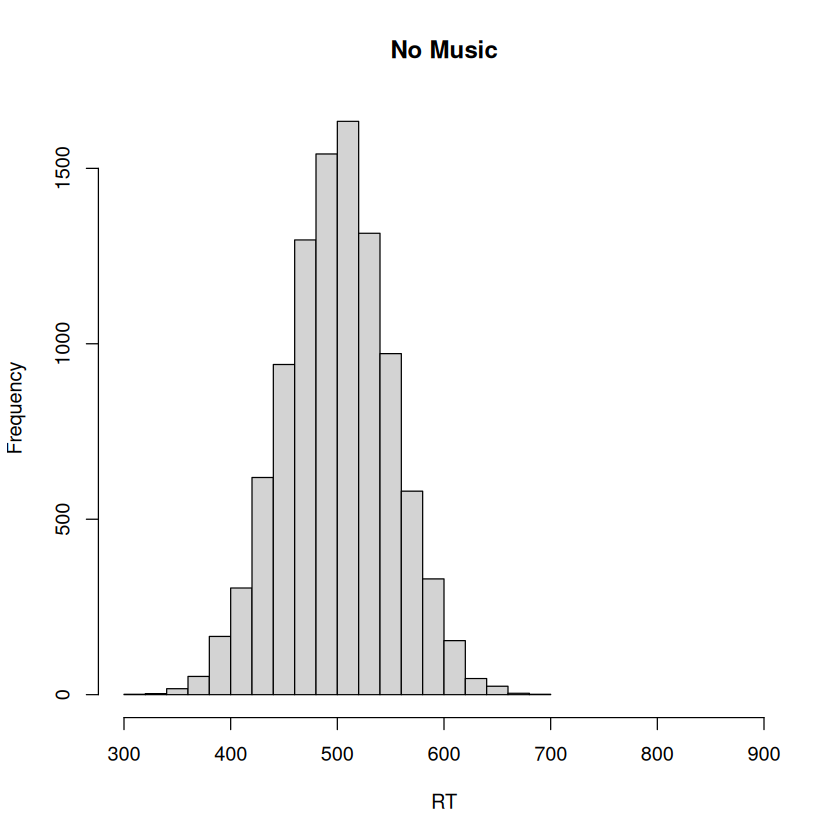

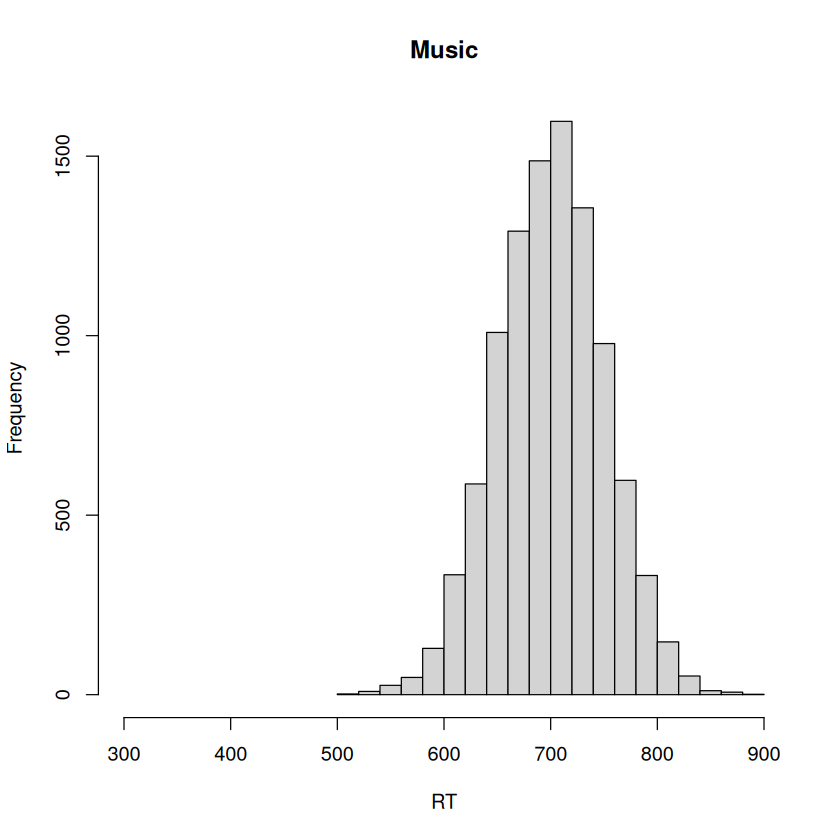

In [11]:
nsims     <- 10000
y.nomusic <- rep(0,nsims)
y.music   <- rep(0,nsims)
x.nomusic <- rep("nomusic",nsims)
x.music   <- rep("music",nsims)

for (i in 1:nsims){
    y.nomusic[i] <- rnorm(n=1, mean=mean.func(i,x.nomusic), sd=sqrt(var.func(i,x.nomusic)))
    y.music[i]   <- rnorm(n=1, mean=mean.func(i,x.music),   sd=sqrt(var.func(i,x.music)))
}

hist(y.nomusic, xlim=c(300,900), main="No Music", xlab="RT")
hist(y.music,   xlim=c(300,900), main="Music",    xlab="RT")

<div class="alert alert-block alert-danger"> 
<b>KEY POINT</b> A statistical model conceptualises every experimental manipulation as a change in the parameters of a probability distribution. How this change happens is captured by the rules that define the mean and variance functions. In combination with the distribution itself, these rules are our <i>model of the data-generating process</i>. The reasons our data appears as it does is because the mean of the distribution shifts across the two experimental conditions. This is our explanation of the <i>systematic</i> variance that we can see. The variance function then provides our explanation of the <i>random noise</i> component of the variance. Different statistical models are formed from choosing different distributions and different mean/variance functions. For example, the difference between multiple regression and an ANOVA is the <i>mean function</i>. In other words, these approaches only differ in the rules they use to change the parameters of the distribution based on additional information. The <i>structure</i> of these models is the same, the only differences lie in the mean and variance functions.
</div>

#### Modelling a Continuous Relationship
In the accompanying lesson, we gave an example of linear regression within the context of a mean function. This is a more complex function that changes the mean of the distribution in relation to some continuous predictor variable. We will not dwell on this here, as we will be covering much more about linear regression in future weeks. However, it might be useful to see how this would be implemented in code as a mean function. An example is given below, where the assumption is that `x` is now some continuous predictor variable, rather than the labels of an experimental condition.

In [12]:
mean.func <- function(i,x){ 
    beta.0 <- 5
    beta.1 <- 0.9
    mu     <- beta.0 + beta.1 * x[i]

    return(mu)
}

### Binomial Example
We will now turn to an example of mean and variance functions within the context of a binomial distribution. Although we will not be using the binomial on the rest of this unit, the point here is to show how the concept of a mean and variance function is *generic* and can be applied to *any distribution*. This is why these ideas are so powerful as a framework for understanding how we can model *any kind of data*. Once you understand the concept of mean and variance functions, you can conceptualise any parameteric statistical model within these terms. Learn the framework once and then apply it to everything. This is how applied statistics really operates, yet this is not a perspective many Psychologists actually have. 

To begin with, the most basic form of a *mean* and *variance* function for the binomial distribution is as follows

$$
\begin{alignat*}{1}
    y_{i}              &\sim \mathcal{B}\left(n_{i},p_{i}\right) \\
    E(y_{i})           &= n_{i}p_{i}                             \\
    \text{Var}(y_{i})  &= n_{i}p_{i}\left(1 - p_{i}\right). 
\end{alignat*}
$$

In words, this says that observation $i$ is drawn from a binomial distribution parameterised by a parameter $n_{i}$ and $p_{i}$. The *expected value* (i.e. the mean) is given by $n_{i}p_{i}$. The *variance* is given by $n_{i}p_{i}\left(1 - p_{i}\right)$. As we saw earlier, the *mean function* and the *variance function* are then the rules we use to assign numeric values to both the mean and variance. The only extra complication here is that the mean and variance are *functions* of the parameters, rather than directly being the parameters, as is the case with the normal distribution.

As before, we can make this more concrete by implementing this situation as a *data simulation* in `R`. Let us go back to the example of detecting auditory stimuli, where the outcome variable is the number of "YES" responses from 20 trials. For this situation, we can specify $n_{i} = n = 20$ and $p_{i} = p = 0.6$ within the mean and variance functions. These values are therefore *constant* irrespective of the particular observation. The only additional complication is that we have to solve for $p$ in order to parameterise the distribution. However, because $n$ is also constant, this is very simple because $p = np/n = E(y_{i})/n$. 

In [13]:
mean.func <- function(i){
    n <- 20
    p <- 0.6
    return(n*p)
}

var.func <- function(i){
    n <- 20
    p <- 0.6
    return(np*(1-p))
}

nsubs <- 20
y     <- rep(0,nsubs)

for (i in 1:nsubs){
    y[i] <- rbinom(n=1, size=n, prob=mean.func(i)/n)
}

y

[1] 12 14 13 14 12 14 12 13 13 12 11 11 15  8 10 17 11 11 11 13

So, this is now equivalent to the model

$$
\begin{alignat*}{2}
    y_{i}              &\sim \mathcal{B}\left(n_{i},p_{i}\right) \\
    E(y_{i})           &= n_{i}p_{i} = 20 \times 0.6   &\quad\text{(Mean functions)}                          \\
    \text{Var}(y_{i})  &= n_{i}p_{i}(1-p_{i}) = 20 \times 0.6 \times 0.4 &\quad \text{(Variance function)}, 
\end{alignat*}
$$

and the code is currently just an overly-complicated way of writing `rbinom(n=50, size=20, prob=0.6)`. However, we will now see how we can use the exact same method as earlier to adapt the model so that the parameter $p$ changes depending upon the condition of the experiment. This will lead to a data-generating model from the binomial distribution that can *accommodate* our experimental manipulations.

#### Modelling an Experimental Manipulation
To see how this framework is generic irrespective of the distribution, let us go back to the example of getting a different group of subjects to listen to some very loud music for 5 minutes. We then get them to try and detect the same faint auditory stimuli as well. Assuming that this manipulation makes subjects *worse* at detecting the stimuli, we could conceptualise this as an *decrease* in the probability of saying "yes". In other words, the experimental manipulation has caused $p$ to change. For instance, perhaps after listening to the loud music, $p = 0.3$ and the data-generating process becomes

$$
y_{i} \sim \mathcal{B}\left(20,0.3\right).
$$

So, we now have a situation where the mean function *changes* the value that it returns depending upon the condition of the experiment. Like before, the rule that governs the value of the mean depends upon which experimental condition the data comes from. The code would then be

In [14]:
mean.func <- function(i,x){ 
    # default values of p and n
    n <- 20
    p <- 0

    # change p depending upon condition
    if (x[i] == "music")   p <- 0.6 
    if (x[i] == "nomusic") p <- 0.3  

    return(n*p)
}

var.func <- function(i,x){
    n  <- 20
    np <- mean.func(i,x)
    p  <- np/n

    return(np*(1-p))
}

# Simulate data from 16 subjects, 8 in the No Music condition and 8 in the Music condition
x     <- c("nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic", 
           "music",   "music",   "music",   "music",   "music",   "music",   "music",   "music")
nsubs <- 16
n     <- 20
y     <- rep(0,nsubs)

for (i in 1:nsubs){
    y[i] <- rbinom(n=1, size=n, p=mean.func(i,x)/n)
}

y

[1]  9  8  7  3  8  8  6  9 12 12 11 11 11 12 11  9

So now, based on the information passed in `x`, we have simulated data where the distribution *changes* depending upon the experimental condition. In this example, the first 8 values are from the No Music condition and the second 8 values are from the Music condition. So now, we have a data-generating model using the binomial distribution *that takes the experimental manipulation into account*.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> As a challenge, can you adapt the code above to simulate the situation where the <i>music</i> and <i>no music</i> conditions have different numbers of trials? Say, <code>n <- 20</code> for music and <code>n <- 15</code> for non-music?. 
</div>

Much like before, this model captures the situation where the data from each condition as being drawn from a *different* binomial distribution. We can again see this illustrated in the histograms below.

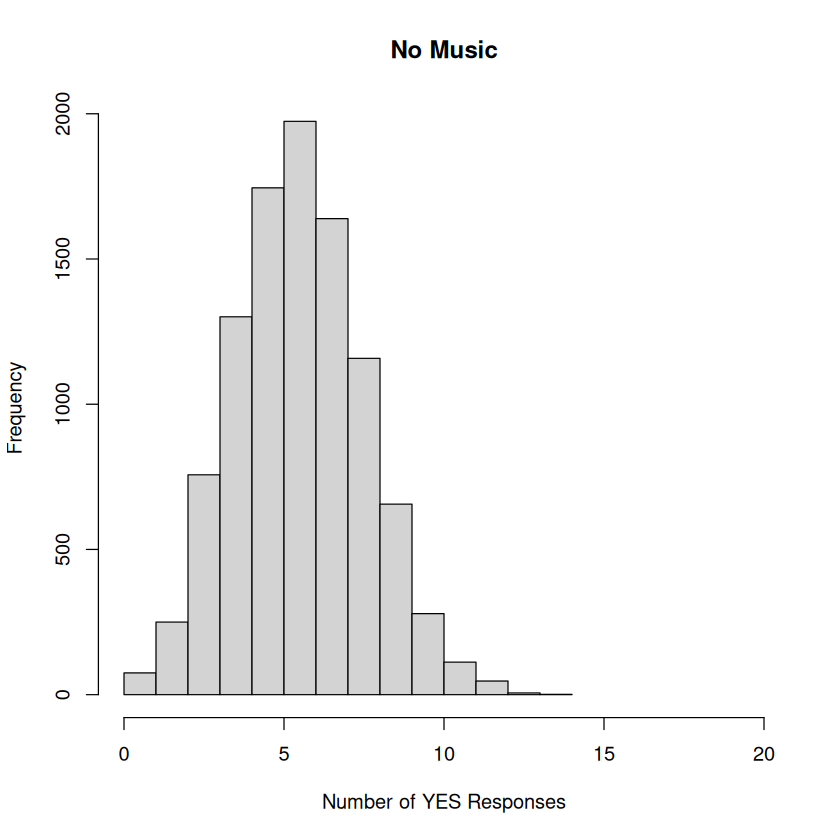

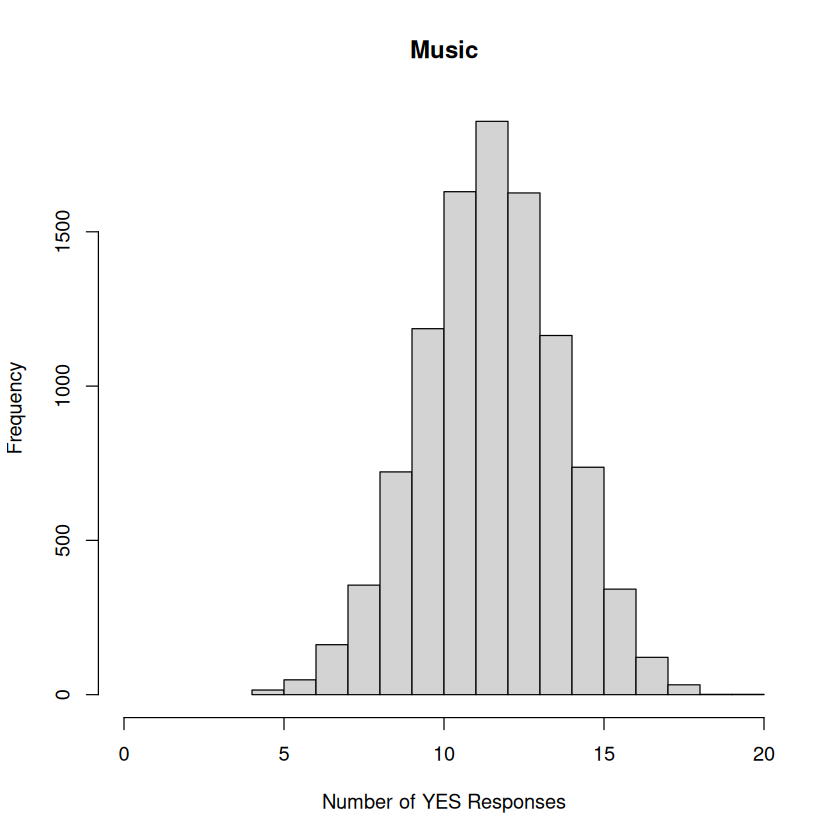

In [17]:
nsims     <- 10000
ntrials   <- 20
y.nomusic <- rep(0,nsims)
y.music   <- rep(0,nsims)
x.nomusic <- rep("nomusic",nsims)
x.music   <- rep("music",nsims)

for (i in 1:nsims){
    y.nomusic[i] <- rbinom(n=1, size=ntrials, prob=mean.func(i,x.nomusic)/ntrials)
    y.music[i]   <- rbinom(n=1, size=ntrials, prob=mean.func(i,x.music)/ntrials)
}

hist(y.nomusic, xlim=c(0,20), main="No Music", xlab="Number of YES Responses")
hist(y.music,   xlim=c(0,20), main="Music",    xlab="Number of YES Responses")

Hopefully it is clear how, much like the normal distribution example, this experimental manipulation is conceptualised as a *change* in the parameters of the probability distribution.

<div class="alert alert-block alert-success"> 
<b>THE BIG PICTURE</b> In all the examples above, we have used different distributions, mean functions, variance functions and parameter values to <i>simulate</i> data. In each case, this is our proposed <i>data-generating process</i>. In other words, it is how we think our data came to be. However, what we do in reality is we collect some data and then propose a data-generating process with <i>unknown</i> parameter values. So, we make a decision on what form the mean and variance functions will take (e.g. a regression model or an ANOVA model) and then use the data to <i>estimate</i> the parameter values that those functions depend upon. So, we do not know what <code>mu</code> and <code>sigma2</code> are, nor what <code>p</code> is. We also do not know how these parameters might change across different experimental conditions. We start by assuming that these data-generating processes are correct (or at least, close enough), but the actual parameter values remain <i>question marks</i>. We have to use real data to try and work out what they are likely to be <i>and</i> how they might change in the presence of experimental manipulations. This is the process of statistical modelling. 
</div>

## Summary
In this workshop we have tried to make some of the abstract theoretical elements of a statitsical model more concrete by provding demonstrations with actual code in `R`. However, because many of these ideas remain somewhat abstract, they may not have fully settled in your mind. This is perfectly fine. Across the next few weeks we will see many examples and this framework should start to feel more comfortable. Remember, the point of all of this is to provide you with a way of conceptualising statistical models so that you can effectively analyse *any* dataset you encounter. That is what makes this framework so powerful. It is like a *superpower*. Rather than spending all your time studying flowcharts in the back of textbooks to decide what to do, you will know immediately how to craft the most suitable model for the data you have. However, because of these lofty ambitions, the framework is needfully high-level and generic at this point. If this is not a problem and you currently feel comfortable, that is excellent. However, if you do not, just have faith that by the time we are done you should be able to return to this workshop and the associated lessons and understand this content much more clearly. This also speaks to the iterative nature of learning. You need to keep coming back to things again and again once you have more information. This is the only way to develop a full understanding of this content. 

<div class="alert alert-block alert-warning"> 
<b>TEST QUESTIONS</b> 

Use the questions below to check your understanding of all the materials from this week.

1. What are the two sources of variance in any dataset?
2. What does it mean to say that a random variable is a <i>variance generator</i>?
3. What do the parameters <i>n</i> and <i>p</i> mean in the context of the binomial distribution?
4. What do the parameters &mu; and &sigma; mean in the context of the normal distribution?
5. How do we usually conceptualise the <i>effect</i> of an experimental manipulation in terms of the parameters of a probability distribution?
6. How do mean and variance functions allow the effect of an experimental manipulation to be integrated into our model of the data-generating process?
7. Do we always have freedom to choose exactly the distribution we want to use to model our data?
8. Can we always rely on the sample distribution to tell us whether our chosen distribution is suitable?
9. Name one possible consequence of using a *continuous* distribution to model a *discrete* outcome.
10. Name one possible consequence of using a *discrete* distribution to model a *continuous* outcome.
</div>